# 04 - Next-Day Daily Total Solar Energy Forecasting & Final Comparison

Notebook này mở rộng đồ án sang bài toán **daily forecasting** để đối sánh tốt hơn với phần *daily prediction* trong bài báo gốc.

Khác với `target_24h` ở notebook 02/03:

- `target_24h`: dự báo giá trị bức xạ/năng lượng **đúng 24 giờ sau** ở cấp hourly.
- `daily_total`: gom 24 giờ thành **tổng năng lượng trong một ngày**, sau đó dự báo **tổng năng lượng của ngày kế tiếp**.

Mục tiêu của notebook:

1. Tạo dataset daily từ dữ liệu hourly đã xử lý ở Ngày 1.
2. Xây dựng target `target_next_day_total_kJ_m2`.
3. Tạo lag/rolling/cyclic/weather/physical features ở cấp ngày.
4. Huấn luyện baseline, ML models, XGBoost/CatBoost và HGBR tuning.
5. Ablation study để kiểm tra đóng góp nhóm feature.
6. Error analysis, feature importance.
7. Tổng hợp kết quả với notebook 02 và 03 để phục vụ báo cáo cuối.

Output được lưu gọn vào:

```text
outputs_04/
figures_04/
models_04/
```

In [1]:
# =========================
# 1. Imports & Configuration
# =========================

from pathlib import Path
import warnings
import time
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("outputs/processed_morocco_hourly_features.csv")
FEATURE_PATH = Path("outputs/feature_columns.csv")

OUT_DIR = Path("outputs_04")
FIG_DIR = Path("figures_04")
MODEL_DIR = Path("models_04")
for d in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Chạy full models
RUN_EXPENSIVE_MODELS = True

print("Configuration ready.")
print("Input data:", DATA_PATH)
print("Output folder:", OUT_DIR)

Configuration ready.
Input data: outputs\processed_morocco_hourly_features.csv
Output folder: outputs_04


## 2. Load hourly processed data

Notebook này dùng file đã xử lý từ Ngày 1:

```text
outputs/processed_morocco_hourly_features.csv
```

File này đã có target hourly, lag/rolling, cyclic và pvlib/physical features. Ở notebook 04, ta chỉ dùng nó làm nguồn dữ liệu hourly để gom thành daily dataset.

In [2]:
# =========================
# 2. Load hourly processed data
# =========================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {DATA_PATH}. Hãy chạy xong notebook 01 trước."
    )

feat_df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
feat_df = feat_df.sort_index()
feat_df = feat_df.loc[:, ~feat_df.columns.duplicated()].copy()

# Đảm bảo index là DatetimeIndex
if not isinstance(feat_df.index, pd.DatetimeIndex):
    feat_df.index = pd.to_datetime(feat_df.index)

print("Hourly processed shape:", feat_df.shape)
print("Date range:", feat_df.index.min(), "→", feat_df.index.max())
print("Duplicated columns:", feat_df.columns.duplicated().sum())

required_cols = ["Solar_Energy_kJ_m2"]
missing_required = [c for c in required_cols if c not in feat_df.columns]
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")

feat_df.head()

Hourly processed shape: (25944, 77)
Date range: 2016-01-15 00:00:00 → 2018-12-30 23:00:00
Duplicated columns: 0


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature,...,pvlib_solar_elevation_deg,pvlib_solar_zenith_deg,pvlib_clear_sky_ghi_Wh_m2,pvlib_clear_sky_index_current,sim_cell_temperature_C,sim_pv_dc_kWh_per_kWp,sim_pv_ac_kWh_per_kWp,sim_pv_ac_lag_1h,sim_pv_ac_lag_24h,sim_pv_ac_lag_168h
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,2016,1,15,0,87.59,2.58,312.0,35.68,0.0,6.87,...,-77.778787,167.778787,0.0,0.0,6.87,0.0,0.0,0.0,0.0,0.0
2016-01-15 01:00:00,2016,1,15,1,87.55,2.59,318.1,36.85,0.0,6.45,...,-77.001686,167.001686,0.0,0.0,6.45,0.0,0.0,0.0,0.0,0.0
2016-01-15 02:00:00,2016,1,15,2,87.51,2.62,321.0,38.12,0.0,6.01,...,-66.650803,156.650803,0.0,0.0,6.01,0.0,0.0,0.0,0.0,0.0
2016-01-15 03:00:00,2016,1,15,3,87.47,2.79,323.5,39.78,0.0,5.39,...,-54.326095,144.326095,0.0,0.0,5.39,0.0,0.0,0.0,0.0,0.0
2016-01-15 04:00:00,2016,1,15,4,87.47,3.07,325.0,41.61,0.0,4.80,...,-41.628519,131.628519,0.0,0.0,4.80,0.0,0.0,0.0,0.0,0.0


## 3. Build daily dataset

Mỗi dòng trong `daily_df` tương ứng với **một ngày D**. Các feature là thông tin đã biết đến hết ngày D. Target là:

```python
target_next_day_total_kJ_m2 = daily_total_kJ_m2.shift(-1)
```

Tức là dùng lịch sử đến ngày D để dự báo tổng năng lượng của ngày D+1.

In [3]:
# =========================
# 3. Build daily dataset
# =========================

def add_daily_stat(daily, hourly, source_col, prefix, funcs):
    # Safely add daily aggregated statistics if source_col exists.
    if source_col not in hourly.columns:
        return daily
    s = pd.to_numeric(hourly[source_col], errors="coerce")
    for func_name, func in funcs.items():
        daily[f"{prefix}_{func_name}"] = s.resample("D").agg(func)
    return daily

# Daily index from hourly data
all_days = pd.date_range(feat_df.index.min().normalize(), feat_df.index.max().normalize(), freq="D")
daily_df = pd.DataFrame(index=all_days)
daily_df.index.name = "date"

# Main target source: total daily solar energy
solar = pd.to_numeric(feat_df["Solar_Energy_kJ_m2"], errors="coerce")
daily_df["daily_total_kJ_m2"] = solar.resample("D").sum()
daily_df["daily_mean_kJ_m2"] = solar.resample("D").mean()
daily_df["daily_max_kJ_m2"] = solar.resample("D").max()
daily_df["valid_hour_count"] = solar.resample("D").count()

# Weather and physical aggregations
agg_specs = [
    ("Solar_Radiation_Wh_m2", "radiation", {"sum": "sum", "mean": "mean", "max": "max"}),
    ("Temperature", "temperature", {"mean": "mean", "max": "max", "min": "min"}),
    ("Humidity", "humidity", {"mean": "mean", "max": "max", "min": "min"}),
    ("Pressure", "pressure", {"mean": "mean"}),
    ("Wind_Speed", "wind_speed", {"mean": "mean", "max": "max"}),
    ("Wind_Direction", "wind_direction", {"mean": "mean"}),
    ("clear_sky_ghi_proxy_Wh_m2", "clear_sky_proxy", {"sum": "sum", "mean": "mean", "max": "max"}),
    ("clear_sky_index_current", "clear_sky_index", {"mean": "mean", "max": "max"}),
    ("pvlib_clear_sky_ghi_Wh_m2", "pvlib_clear_sky", {"sum": "sum", "mean": "mean", "max": "max"}),
    ("pvlib_clear_sky_index_current", "pvlib_clear_sky_index", {"mean": "mean", "max": "max"}),
    ("solar_elevation_approx_deg", "solar_elevation", {"mean": "mean", "max": "max"}),
    ("pvlib_solar_elevation_deg", "pvlib_solar_elevation", {"mean": "mean", "max": "max"}),
    ("sim_cell_temperature_C", "sim_cell_temperature", {"mean": "mean", "max": "max"}),
    ("sim_pv_dc_kWh_per_kWp", "sim_pv_dc", {"sum": "sum", "mean": "mean", "max": "max"}),
    ("sim_pv_ac_kWh_per_kWp", "sim_pv_ac", {"sum": "sum", "mean": "mean", "max": "max"}),
]

for source_col, prefix, funcs in agg_specs:
    daily_df = add_daily_stat(daily_df, feat_df, source_col, prefix, funcs)

# Chỉ giữ ngày có đủ tương đối số giờ. Vì processed hourly đã mất một phần đầu/cuối, dùng ngưỡng 20h để an toàn.
daily_df = daily_df[daily_df["valid_hour_count"] >= 20].copy()

print("Daily dataset before feature engineering:", daily_df.shape)
print("Date range:", daily_df.index.min(), "→", daily_df.index.max())
display(daily_df.head())

Daily dataset before feature engineering: (1081, 39)
Date range: 2016-01-15 00:00:00 → 2018-12-30 00:00:00


,daily_total_kJ_m2,daily_mean_kJ_m2,daily_max_kJ_m2,valid_hour_count,radiation_sum,radiation_mean,radiation_max,temperature_mean,temperature_max,temperature_min,...,pvlib_solar_elevation_mean,pvlib_solar_elevation_max,sim_cell_temperature_mean,sim_cell_temperature_max,sim_pv_dc_sum,sim_pv_dc_mean,sim_pv_dc_max,sim_pv_ac_sum,sim_pv_ac_mean,sim_pv_ac_max
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15,13153.932,548.0805,2092.212,24,3653.87,152.244583,581.17,11.249167,21.19,4.36,...,-14.593424,36.508644,16.006810,38.591563,3.538663,0.147444,0.549574,3.397117,0.141547,0.527591
2016-01-16,15830.640,659.6100,2515.968,24,4397.40,183.225000,698.88,7.928750,16.16,1.20,...,-14.474203,36.682299,13.654531,36.420000,4.307688,0.179487,0.666955,4.135380,0.172308,0.640277
2016-01-17,15401.556,641.7315,2438.568,24,4278.21,178.258750,677.38,7.511667,16.16,2.27,...,-14.350421,36.862711,13.082253,35.720000,4.196970,0.174874,0.648393,4.029091,0.167879,0.622457
2016-01-18,11078.460,461.6025,1672.632,24,3077.35,128.222917,464.62,8.882500,18.42,2.31,...,-14.222111,37.049809,12.889466,32.421875,3.049731,0.127072,0.454567,2.927742,0.121989,0.436384
2016-01-19,15012.468,625.5195,2404.800,24,4170.13,173.755417,668.00,9.513750,17.88,2.89,...,-14.089308,37.243519,14.943607,38.545000,4.048176,0.168674,0.631808,3.886249,0.161927,0.606535


## 4. Daily feature engineering

Nhóm feature chính:

- Cyclic time features: `doy_sin`, `doy_cos`, `month_sin`, `month_cos`.
- Daily total lags: 1, 2, 3, 6, 7, 14, 30 ngày.
- Rolling statistics: 3, 7, 14, 30 ngày.
- Seasonal persistence feature cho target ngày kế tiếp: tổng năng lượng của ngày cùng thứ tuần trước.
- Weather/physical daily aggregated features.

In [4]:
# =========================
# 4. Daily feature engineering
# =========================

out = daily_df.copy()

# Calendar features
out["day_of_year"] = out.index.dayofyear
out["month"] = out.index.month
out["day_of_week"] = out.index.dayofweek

out["doy_sin"] = np.sin(2 * np.pi * out["day_of_year"] / 365.25)
out["doy_cos"] = np.cos(2 * np.pi * out["day_of_year"] / 365.25)
out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)

# Target: next-day total solar energy
target_col = "target_next_day_total_kJ_m2"
out[target_col] = out["daily_total_kJ_m2"].shift(-1)

# Daily lags of current target source
for lag in [1, 2, 3, 6, 7, 14, 30]:
    out[f"daily_total_lag_{lag}d"] = out["daily_total_kJ_m2"].shift(lag)

# Seasonal persistence for target day D+1: value at D+1-7 = D-6
out["seasonal7_for_target"] = out["daily_total_kJ_m2"].shift(6)

# Rolling features based only on past values: shift(1) before rolling
shifted_total = out["daily_total_kJ_m2"].shift(1)
for window in [3, 7, 14, 30]:
    out[f"daily_total_roll_mean_{window}d"] = shifted_total.rolling(window).mean()
    out[f"daily_total_roll_std_{window}d"] = shifted_total.rolling(window).std()
    out[f"daily_total_roll_min_{window}d"] = shifted_total.rolling(window).min()
    out[f"daily_total_roll_max_{window}d"] = shifted_total.rolling(window).max()

# Optional lagged weather/physical features: previous day and previous week
lag_base_candidates = [
    "temperature_mean", "temperature_max", "temperature_min",
    "humidity_mean", "pressure_mean", "wind_speed_mean",
    "radiation_sum", "clear_sky_index_mean", "pvlib_clear_sky_index_mean",
    "sim_pv_ac_sum", "sim_cell_temperature_mean",
]
for col in lag_base_candidates:
    if col in out.columns:
        out[f"{col}_lag_1d"] = out[col].shift(1)
        out[f"{col}_lag_7d"] = out[col].shift(7)

# Clean invalid values
out = out.replace([np.inf, -np.inf], np.nan)
feature_df = out.dropna().copy()

print("Daily feature dataframe:", feature_df.shape)
print("Date range after lags/target:", feature_df.index.min(), "→", feature_df.index.max())
print("Number of columns:", feature_df.shape[1])
display(feature_df.head())

Daily feature dataframe: (1050, 95)
Date range after lags/target: 2016-02-14 00:00:00 → 2018-12-29 00:00:00
Number of columns: 95


,daily_total_kJ_m2,daily_mean_kJ_m2,daily_max_kJ_m2,valid_hour_count,radiation_sum,radiation_mean,radiation_max,temperature_mean,temperature_max,temperature_min,...,radiation_sum_lag_1d,radiation_sum_lag_7d,clear_sky_index_mean_lag_1d,clear_sky_index_mean_lag_7d,pvlib_clear_sky_index_mean_lag_1d,pvlib_clear_sky_index_mean_lag_7d,sim_pv_ac_sum_lag_1d,sim_pv_ac_sum_lag_7d,sim_cell_temperature_mean_lag_1d,sim_cell_temperature_mean_lag_7d
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14,18930.096,788.7540,2821.140,24,5258.36,219.098333,783.65,11.228333,19.36,6.44,...,4087.63,4375.78,0.340725,0.387313,0.351687,0.397415,3.733152,4.034945,19.649102,16.878880
2016-02-15,18862.596,785.9415,2899.692,24,5239.61,218.317083,805.47,5.075000,8.72,1.63,...,5258.36,5000.98,0.433637,0.433210,0.447573,0.445708,4.817420,4.541030,18.075156,18.839609
2016-02-16,17171.208,715.4670,2727.000,24,4769.78,198.740833,757.50,2.711250,7.82,-1.09,...,5239.61,5070.50,0.421931,0.435168,0.436583,0.447634,4.987782,4.559455,11.897409,20.669714
2016-02-17,19696.428,820.6845,2938.140,24,5471.23,227.967917,816.15,3.380417,11.67,-4.02,...,4769.78,5131.74,0.378625,0.437514,0.402061,0.449459,4.589461,4.614349,8.921901,20.590286
2016-02-18,19350.396,806.2665,2899.512,24,5375.11,223.962917,805.42,5.310833,13.93,-1.24,...,5471.23,4873.39,0.440643,0.406256,0.451510,0.424802,5.172514,4.427842,10.504414,19.219310


## 5. Train / Validation / Test split

Chia theo thời gian tương tự các notebook trước:

- Train: đến hết 2017.
- Validation: 2018-01 đến 2018-06.
- Test: 2018-07 đến cuối chuỗi.

Vì target là ngày kế tiếp nên ngày cuối cùng bị loại trước đó.

In [5]:
# =========================
# 5. Train / Validation / Test split
# =========================

train_df = feature_df.loc[:"2017-12-31"].copy()
val_df = feature_df.loc["2018-01-01":"2018-06-30"].copy()
test_df = feature_df.loc["2018-07-01":"2018-12-31"].copy()

# Numeric feature columns
forbidden_cols = [
    target_col,
    "day_of_year", "month", "day_of_week",  # giữ cyclic thay vì raw calendar integer
]

feature_cols = [
    c for c in feature_df.columns
    if c not in forbidden_cols
    and pd.api.types.is_numeric_dtype(feature_df[c])
    and feature_df[c].nunique(dropna=True) > 1
]
feature_cols = list(dict.fromkeys(feature_cols))

print("Train:", train_df.shape, train_df.index.min(), "→", train_df.index.max())
print("Val  :", val_df.shape, val_df.index.min(), "→", val_df.index.max())
print("Test :", test_df.shape, test_df.index.min(), "→", test_df.index.max())
print("Number of features:", len(feature_cols))

pd.Series(feature_cols, name="feature").to_csv(OUT_DIR / "04_daily_feature_columns.csv", index=False)
feature_df.to_csv(OUT_DIR / "04_daily_feature_dataset.csv")

Train: (687, 95) 2016-02-14 00:00:00 → 2017-12-31 00:00:00
Val  : (181, 95) 2018-01-01 00:00:00 → 2018-06-30 00:00:00
Test : (182, 95) 2018-07-01 00:00:00 → 2018-12-29 00:00:00
Number of features: 90


## 6. Metrics and utility functions

In [6]:
# =========================
# 6. Metrics and utilities
# =========================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_predictions(y_true, y_pred, persistence_pred=None, seasonal_pred=None):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[-n:]
    y_pred = y_pred[-n:]

    value_range = y_true.max() - y_true.min()
    out = {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "MaxError": float(max_error(y_true, y_pred)),
        "NRMSE": float(rmse(y_true, y_pred) / value_range) if value_range != 0 else np.nan,
    }

    if persistence_pred is not None:
        p = np.asarray(persistence_pred).reshape(-1)
        m = min(len(y_true), len(p))
        y_skill = y_true[-m:]
        p = p[-m:]
        p_rmse = rmse(y_skill, p)
        out["skill_vs_persistence"] = float(1 - out["RMSE"] / p_rmse) if p_rmse > 0 else np.nan
        out["persistence_RMSE"] = p_rmse
    else:
        out["skill_vs_persistence"] = np.nan
        out["persistence_RMSE"] = np.nan

    if seasonal_pred is not None:
        s = np.asarray(seasonal_pred).reshape(-1)
        m = min(len(y_true), len(s))
        y_skill = y_true[-m:]
        s = s[-m:]
        s_rmse = rmse(y_skill, s)
        out["skill_vs_seasonal7"] = float(1 - out["RMSE"] / s_rmse) if s_rmse > 0 else np.nan
        out["seasonal7_RMSE"] = s_rmse
    else:
        out["skill_vs_seasonal7"] = np.nan
        out["seasonal7_RMSE"] = np.nan

    return out


def make_clean_X(dataframe, cols):
    cols = list(dict.fromkeys([c for c in cols if c in dataframe.columns]))
    X = dataframe.loc[:, cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X.astype(np.float32)


def print_metric_short(name, metrics):
    print(
        f"{name:<28} | RMSE={metrics['RMSE']:.2f} | MAE={metrics['MAE']:.2f} | "
        f"R2={metrics['R2']:.4f} | Skill={metrics.get('skill_vs_persistence', np.nan):.4f}"
    )


def add_result_row(results, model_name, model_type, val_metrics, test_metrics, n_features, train_seconds, extra=None):
    row = {
        "target": target_col,
        "model": model_name,
        "model_type": model_type,
        "n_features": n_features,
        "train_seconds": train_seconds,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    if extra:
        row.update(extra)
    results.append(row)

## 7. Baselines and machine learning models

Các baseline:

- `Persistence`: dự báo tổng ngày mai bằng tổng ngày hôm nay.
- `SeasonalPersistence7d`: dự báo tổng ngày mai bằng tổng của ngày cùng thứ tuần trước.

Các mô hình chính:

- Linear Regression / Ridge / SVR / MLP
- Random Forest / HGBR
- XGBoost / CatBoost

In [7]:
# =========================
# 7. Baselines and ML models
# =========================

results = []
predictions = {}
trained_models = {}

X_train = make_clean_X(train_df, feature_cols)
X_val = make_clean_X(val_df, feature_cols)
X_test = make_clean_X(test_df, feature_cols)

y_train = train_df[target_col].astype(np.float32).values
y_val = val_df[target_col].astype(np.float32).values
y_test = test_df[target_col].astype(np.float32).values

p_val = val_df["daily_total_kJ_m2"].astype(np.float32).values
p_test = test_df["daily_total_kJ_m2"].astype(np.float32).values
s_val = val_df["seasonal7_for_target"].astype(np.float32).values
s_test = test_df["seasonal7_for_target"].astype(np.float32).values

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)
print("Duplicated columns:", X_train.columns.duplicated().sum())

# Baseline 1: Persistence
val_pred = np.clip(p_val, 0, None)
test_pred = np.clip(p_test, 0, None)
val_metrics = evaluate_predictions(y_val, val_pred, persistence_pred=p_val, seasonal_pred=s_val)
test_metrics = evaluate_predictions(y_test, test_pred, persistence_pred=p_test, seasonal_pred=s_test)
add_result_row(results, "Persistence", "baseline", val_metrics, test_metrics, 1, 0.0)
predictions["Persistence"] = {"val_pred": val_pred, "test_pred": test_pred}
print_metric_short("Persistence Val", val_metrics)
print_metric_short("Persistence Test", test_metrics)

# Baseline 2: Seasonal persistence 7d
val_pred = np.clip(s_val, 0, None)
test_pred = np.clip(s_test, 0, None)
val_metrics = evaluate_predictions(y_val, val_pred, persistence_pred=p_val, seasonal_pred=s_val)
test_metrics = evaluate_predictions(y_test, test_pred, persistence_pred=p_test, seasonal_pred=s_test)
add_result_row(results, "SeasonalPersistence7d", "baseline", val_metrics, test_metrics, 1, 0.0)
predictions["SeasonalPersistence7d"] = {"val_pred": val_pred, "test_pred": test_pred}
print_metric_short("Seasonal7 Val", val_metrics)
print_metric_short("Seasonal7 Test", test_metrics)

ml_models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0, random_state=SEED))
    ]),
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(C=10.0, epsilon=0.1, gamma="scale"))
    ]),
    "MLPRegressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=SEED,
        ))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=SEED,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=700,
        learning_rate=0.04,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
    ),
    "CatBoost": CatBoostRegressor(
        iterations=700,
        learning_rate=0.04,
        depth=5,
        loss_function="RMSE",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
    ),
}

if not RUN_EXPENSIVE_MODELS:
    ml_models = {k: v for k, v in ml_models.items() if k not in ["SVR_RBF", "MLPRegressor", "RandomForest"]}

for model_name, model in ml_models.items():
    print("\n" + "-" * 80)
    print("Training", model_name)
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    val_pred = np.clip(model.predict(X_val), 0, None)
    test_pred = np.clip(model.predict(X_test), 0, None)

    val_metrics = evaluate_predictions(y_val, val_pred, persistence_pred=p_val, seasonal_pred=s_val)
    test_metrics = evaluate_predictions(y_test, test_pred, persistence_pred=p_test, seasonal_pred=s_test)

    add_result_row(results, model_name, "daily_ml", val_metrics, test_metrics, X_train.shape[1], elapsed)
    predictions[model_name] = {"val_pred": val_pred, "test_pred": test_pred}
    trained_models[model_name] = model

    joblib.dump(model, MODEL_DIR / f"04_daily_{model_name}.joblib")
    print_metric_short(f"{model_name} Val", val_metrics)
    print_metric_short(f"{model_name} Test", test_metrics)

results_df = pd.DataFrame(results).sort_values("val_RMSE")
display(results_df[["model", "model_type", "val_RMSE", "test_RMSE", "test_R2", "test_skill_vs_persistence", "test_skill_vs_seasonal7"]])

X_train: (687, 90)
X_val  : (181, 90)
X_test : (182, 90)
Duplicated columns: 0
Persistence Val              | RMSE=3434.69 | MAE=2271.19 | R2=0.7320 | Skill=0.0000
Persistence Test             | RMSE=3207.41 | MAE=2185.73 | R2=0.6524 | Skill=0.0000
Seasonal7 Val                | RMSE=4436.77 | MAE=3101.72 | R2=0.5528 | Skill=-0.2918
Seasonal7 Test               | RMSE=4332.43 | MAE=3067.78 | R2=0.3658 | Skill=-0.3508

--------------------------------------------------------------------------------
Training LinearRegression
LinearRegression Val         | RMSE=2939.14 | MAE=2138.93 | R2=0.8037 | Skill=0.1443
LinearRegression Test        | RMSE=3239.30 | MAE=2204.43 | R2=0.6455 | Skill=-0.0099

--------------------------------------------------------------------------------
Training Ridge
Ridge Val                    | RMSE=2816.78 | MAE=2046.59 | R2=0.8197 | Skill=0.1799
Ridge Test                   | RMSE=2978.16 | MAE=2033.86 | R2=0.7003 | Skill=0.0715

--------------------------------

,model,model_type,val_RMSE,test_RMSE,test_R2,test_skill_vs_persistence,test_skill_vs_seasonal7
3,Ridge,daily_ml,2816.775639,2978.157484,0.700323,0.071475,0.312590
6,RandomForest,daily_ml,2830.914016,2815.794336,0.732108,0.122096,0.350066
7,HistGradientBoosting,daily_ml,2922.741025,3120.318086,0.671031,0.027152,0.279777
2,LinearRegression,daily_ml,2939.142392,3239.303320,0.645464,-0.009945,0.252313
9,CatBoost,daily_ml,2943.558890,2872.004277,0.721306,0.104571,0.337092
8,XGBoost,daily_ml,2962.176902,3043.097435,0.687112,0.051228,0.297601
0,Persistence,baseline,3434.688487,3207.405805,0.652411,0.000000,0.259675
1,SeasonalPersistence7d,baseline,4436.768419,4332.431419,0.365808,-0.350759,0.000000
4,SVR_RBF,daily_ml,6002.759054,5406.123293,0.012517,-0.685513,-0.247827
5,MLPRegressor,daily_ml,9068.103220,10388.333456,-2.646275,-2.238858,-1.397807


## 8. HGBR tuning

`HistGradientBoostingRegressor` là mô hình boosting có sẵn trong scikit-learn, thường mạnh và nhanh trên dữ liệu bảng. Phần này thử một số cấu hình nhỏ, chọn theo **validation RMSE**, không chọn theo test set.

In [8]:
# =========================
# 8. HGBR tuning
# =========================

hgbr_tuning_results = []

hgbr_param_grid = [
    {"learning_rate": 0.03, "max_iter": 700, "max_leaf_nodes": 31, "l2_regularization": 0.1},
    {"learning_rate": 0.04, "max_iter": 700, "max_leaf_nodes": 31, "l2_regularization": 0.1},
    {"learning_rate": 0.04, "max_iter": 700, "max_leaf_nodes": 63, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_iter": 600, "max_leaf_nodes": 31, "l2_regularization": 1.0},
]

for i, params in enumerate(hgbr_param_grid, start=1):
    model_name = f"HGBR_tuned_{i}"
    print("\n" + "-" * 80)
    print(model_name, params)

    model = HistGradientBoostingRegressor(
        **params,
        random_state=SEED,
    )

    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    val_pred = np.clip(model.predict(X_val), 0, None)
    test_pred = np.clip(model.predict(X_test), 0, None)

    val_metrics = evaluate_predictions(y_val, val_pred, persistence_pred=p_val, seasonal_pred=s_val)
    test_metrics = evaluate_predictions(y_test, test_pred, persistence_pred=p_test, seasonal_pred=s_test)

    row = {
        "target": target_col,
        "model": model_name,
        "model_type": "daily_hgbr_tuning",
        "n_features": X_train.shape[1],
        "train_seconds": elapsed,
        "params": json.dumps(params),
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    hgbr_tuning_results.append(row)
    results.append(row)
    predictions[model_name] = {"val_pred": val_pred, "test_pred": test_pred}
    trained_models[model_name] = model
    joblib.dump(model, MODEL_DIR / f"04_daily_{model_name}.joblib")

    print_metric_short(f"{model_name} Val", val_metrics)
    print_metric_short(f"{model_name} Test", test_metrics)

hgbr_tuning_df = pd.DataFrame(hgbr_tuning_results).sort_values("val_RMSE")
display(hgbr_tuning_df[["model", "val_RMSE", "test_RMSE", "test_R2", "params"]])

# Update global results_df
results_df = pd.DataFrame(results).sort_values("val_RMSE")


--------------------------------------------------------------------------------
HGBR_tuned_1 {'learning_rate': 0.03, 'max_iter': 700, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
HGBR_tuned_1 Val             | RMSE=2888.44 | MAE=2038.01 | R2=0.8105 | Skill=0.1590
HGBR_tuned_1 Test            | RMSE=3164.44 | MAE=2158.99 | R2=0.6617 | Skill=0.0134

--------------------------------------------------------------------------------
HGBR_tuned_2 {'learning_rate': 0.04, 'max_iter': 700, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
HGBR_tuned_2 Val             | RMSE=2930.17 | MAE=2065.70 | R2=0.8049 | Skill=0.1469
HGBR_tuned_2 Test            | RMSE=3134.32 | MAE=2118.04 | R2=0.6681 | Skill=0.0228

--------------------------------------------------------------------------------
HGBR_tuned_3 {'learning_rate': 0.04, 'max_iter': 700, 'max_leaf_nodes': 63, 'l2_regularization': 0.1}
HGBR_tuned_3 Val             | RMSE=2930.17 | MAE=2065.70 | R2=0.8049 | Skill=0.1469
HGBR_tuned_3 Test      

,model,val_RMSE,test_RMSE,test_R2,params
0,HGBR_tuned_1,2888.439213,3164.437022,0.661662,"{""learning_rate"": 0.03, ""max_iter"": 700, ""max_..."
1,HGBR_tuned_2,2930.170942,3134.320257,0.668072,"{""learning_rate"": 0.04, ""max_iter"": 700, ""max_..."
2,HGBR_tuned_3,2930.170942,3134.320257,0.668072,"{""learning_rate"": 0.04, ""max_iter"": 700, ""max_..."
3,HGBR_tuned_4,2947.179634,3139.273496,0.667022,"{""learning_rate"": 0.05, ""max_iter"": 600, ""max_..."


## 9. Ablation study

Ablation giúp trả lời câu hỏi: nhóm feature nào thật sự đóng góp cho daily forecasting?

Ta dùng HGBR làm mô hình cố định và thay đổi bộ feature.

In [9]:
# =========================
# 9. Ablation study
# =========================

# Define feature groups safely
all_cols = set(feature_cols)

time_features = [c for c in ["doy_sin", "doy_cos", "month_sin", "month_cos", "dow_sin", "dow_cos"] if c in all_cols]

lag_features = [c for c in feature_cols if "daily_total_lag" in c or c in ["daily_total_kJ_m2", "seasonal7_for_target"]]
rolling_features = [c for c in feature_cols if "daily_total_roll" in c]

weather_features = [
    c for c in feature_cols
    if any(key in c for key in ["temperature", "humidity", "pressure", "wind_speed", "wind_direction"])
]
physical_features = [
    c for c in feature_cols
    if any(key in c for key in ["clear_sky", "pvlib", "solar_elevation", "sim_pv", "sim_cell", "radiation"])
]

feature_sets = {
    "A0_time_only": time_features,
    "A1_time_weather": list(dict.fromkeys(time_features + weather_features)),
    "A2_add_lags": list(dict.fromkeys(time_features + weather_features + lag_features)),
    "A3_add_rolling": list(dict.fromkeys(time_features + weather_features + lag_features + rolling_features)),
    "A4_add_physical": list(dict.fromkeys(time_features + weather_features + lag_features + rolling_features + physical_features)),
    "A5_full": feature_cols,
}

ablation_results = []

for set_name, cols in feature_sets.items():
    cols = [c for c in list(dict.fromkeys(cols)) if c in feature_cols]
    if len(cols) == 0:
        continue

    Xtr = make_clean_X(train_df, cols)
    Xv = make_clean_X(val_df, cols)
    Xt = make_clean_X(test_df, cols)

    model = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=SEED,
    )

    start = time.time()
    model.fit(Xtr, y_train)
    elapsed = time.time() - start

    val_pred = np.clip(model.predict(Xv), 0, None)
    test_pred = np.clip(model.predict(Xt), 0, None)

    val_metrics = evaluate_predictions(y_val, val_pred, persistence_pred=p_val, seasonal_pred=s_val)
    test_metrics = evaluate_predictions(y_test, test_pred, persistence_pred=p_test, seasonal_pred=s_test)

    row = {
        "feature_set": set_name,
        "n_features": len(cols),
        "train_seconds": elapsed,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    ablation_results.append(row)
    print_metric_short(f"{set_name} Val", val_metrics)
    print_metric_short(f"{set_name} Test", test_metrics)

ablation_df = pd.DataFrame(ablation_results).sort_values("val_RMSE")
display(ablation_df[["feature_set", "n_features", "val_RMSE", "test_RMSE", "test_R2"]])

A0_time_only Val             | RMSE=3397.11 | MAE=2437.71 | R2=0.7378 | Skill=0.0109
A0_time_only Test            | RMSE=3371.10 | MAE=2336.66 | R2=0.6160 | Skill=-0.0510
A1_time_weather Val          | RMSE=3124.81 | MAE=2206.69 | R2=0.7782 | Skill=0.0902
A1_time_weather Test         | RMSE=3144.28 | MAE=2103.93 | R2=0.6660 | Skill=0.0197
A2_add_lags Val              | RMSE=2988.57 | MAE=2095.00 | R2=0.7971 | Skill=0.1299
A2_add_lags Test             | RMSE=2980.47 | MAE=2008.73 | R2=0.6999 | Skill=0.0708
A3_add_rolling Val           | RMSE=2963.36 | MAE=2095.53 | R2=0.8005 | Skill=0.1372
A3_add_rolling Test          | RMSE=2999.99 | MAE=2092.52 | R2=0.6959 | Skill=0.0647
A4_add_physical Val          | RMSE=2922.89 | MAE=2066.43 | R2=0.8059 | Skill=0.1490
A4_add_physical Test         | RMSE=3119.71 | MAE=2099.75 | R2=0.6712 | Skill=0.0273
A5_full Val                  | RMSE=2922.74 | MAE=2066.34 | R2=0.8059 | Skill=0.1491
A5_full Test                 | RMSE=3120.32 | MAE=2104.14 | R2=0

,feature_set,n_features,val_RMSE,test_RMSE,test_R2
5,A5_full,90,2922.741025,3120.318086,0.671031
4,A4_add_physical,88,2922.889314,3119.708377,0.671159
3,A3_add_rolling,57,2963.364660,2999.987879,0.695914
2,A2_add_lags,41,2988.571202,2980.471672,0.699857
1,A1_time_weather,32,3124.807177,3144.282026,0.665958
0,A0_time_only,6,3397.108124,3371.103801,0.616026


## 10. Select best daily model and visualize predictions

Model chính thức được chọn theo **validation RMSE** để tránh chọn theo test set.

Best daily model selected by validation RMSE: Ridge


,target,model,model_type,n_features,train_seconds,val_MAE,val_RMSE,val_R2,val_MaxError,val_NRMSE,...,test_MAE,test_RMSE,test_R2,test_MaxError,test_NRMSE,test_skill_vs_persistence,test_persistence_RMSE,test_skill_vs_seasonal7,test_seasonal7_RMSE,params
3,target_next_day_total_kJ_m2,Ridge,daily_ml,90,0.012261,2046.592407,2816.775639,0.819748,11431.199219,0.100449,...,2033.855713,2978.157484,0.700323,15944.808594,0.119338,0.071475,3207.405805,0.31259,4332.431419,NaN


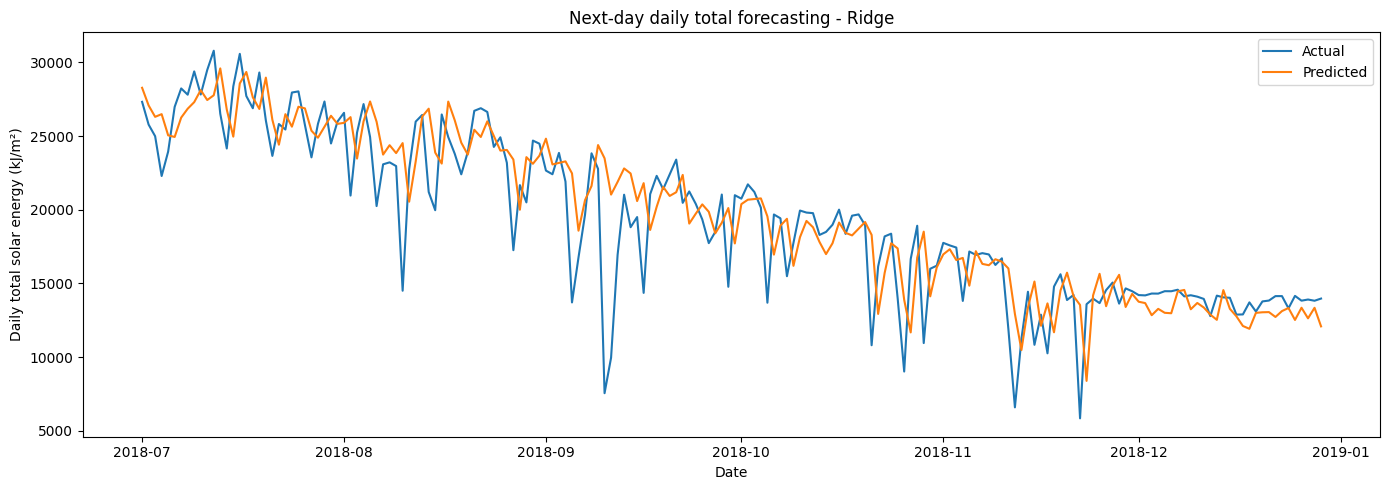

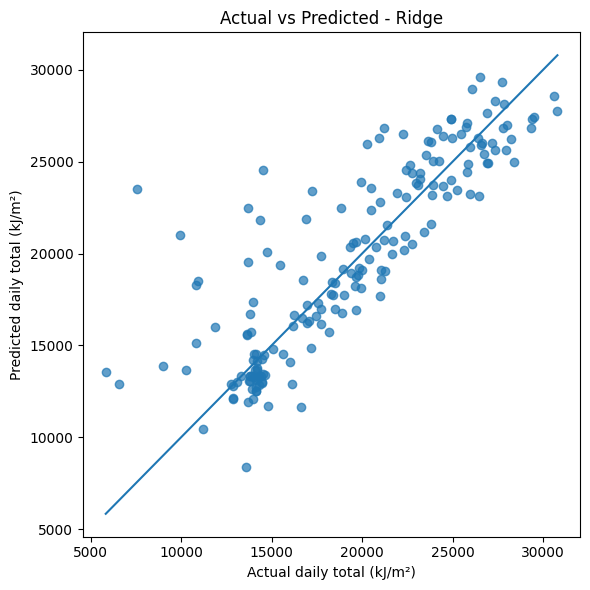

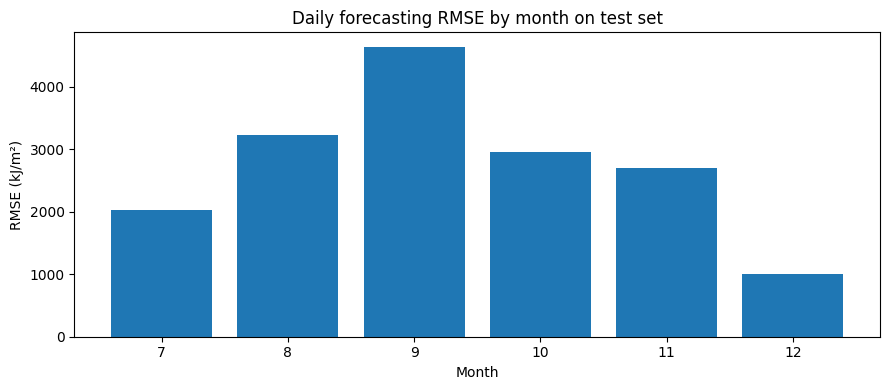

,month,MAE,RMSE,count
0,7,1809.727783,2027.080688,31
1,8,2400.883545,3224.775146,31
2,9,3103.059326,4637.802734,30
3,10,2126.267822,2962.715576,31
4,11,1872.389282,2692.433838,30
5,12,843.276794,1010.618164,29


In [10]:
# =========================
# 10. Best model and plots
# =========================

results_df = pd.DataFrame(results).sort_values("val_RMSE")
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
print("Best daily model selected by validation RMSE:", best_model_name)
display(best_row.to_frame().T)

best_test_pred = predictions[best_model_name]["test_pred"]
best_val_pred = predictions[best_model_name]["val_pred"]

# Align for plotting
n_test = min(len(y_test), len(best_test_pred))
plot_index = pd.DatetimeIndex(test_df.index)[-n_test:]
y_test_plot = y_test[-n_test:]
pred_test_plot = np.asarray(best_test_pred).reshape(-1)[-n_test:]

# Actual vs predicted time series
plt.figure(figsize=(14, 5))
plt.plot(plot_index, y_test_plot, label="Actual")
plt.plot(plot_index, pred_test_plot, label="Predicted")
plt.title(f"Next-day daily total forecasting - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Daily total solar energy (kJ/m²)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_daily_actual_vs_predicted.png", dpi=160)
plt.show()

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test_plot, pred_test_plot, alpha=0.7)
lims = [min(y_test_plot.min(), pred_test_plot.min()), max(y_test_plot.max(), pred_test_plot.max())]
plt.plot(lims, lims)
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual daily total (kJ/m²)")
plt.ylabel("Predicted daily total (kJ/m²)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_daily_scatter_actual_predicted.png", dpi=160)
plt.show()

# Residual by month
residual = pred_test_plot - y_test_plot
error_df = pd.DataFrame({
    "date": plot_index,
    "actual": y_test_plot,
    "predicted": pred_test_plot,
    "residual": residual,
    "abs_error": np.abs(residual),
})
error_df["month"] = error_df["date"].dt.month
monthly_error = error_df.groupby("month").agg(
    MAE=("abs_error", "mean"),
    RMSE=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
    count=("residual", "size"),
).reset_index()

plt.figure(figsize=(9, 4))
plt.bar(monthly_error["month"], monthly_error["RMSE"])
plt.title("Daily forecasting RMSE by month on test set")
plt.xlabel("Month")
plt.ylabel("RMSE (kJ/m²)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_daily_rmse_by_month.png", dpi=160)
plt.show()

display(monthly_error)

## 11. Permutation feature importance

Permutation importance được dùng như phân tích định tính để xem nhóm biến nào tác động mạnh đến mô hình daily tốt nhất.

Computing permutation importance for: Ridge


,feature,importance_mean,importance_std
24,pvlib_clear_sky_index_mean,181.451929,82.141346
14,wind_speed_max,158.090283,27.653295
8,temperature_min,122.047070,39.196835
49,daily_total_lag_14d,94.650659,36.340521
74,humidity_mean_lag_1d,85.183179,45.243215
11,humidity_min,75.611328,49.254818
61,daily_total_roll_std_14d,68.982935,24.246203
41,month_cos,62.155298,27.836503
6,temperature_mean,60.752002,26.999851
5,radiation_max,55.182446,28.727940


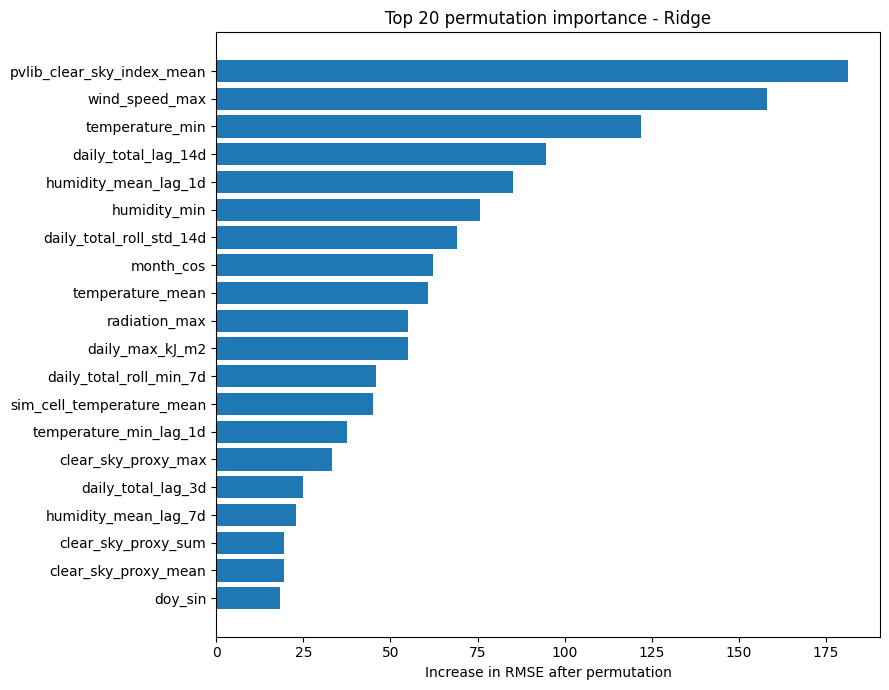

In [11]:
# =========================
# 11. Feature importance
# =========================

feature_importance_df = pd.DataFrame()

if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
    print("Computing permutation importance for:", best_model_name)

    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=SEED,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    feature_importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    display(feature_importance_df.head(20))

    top_imp = feature_importance_df.head(20).sort_values("importance_mean")
    plt.figure(figsize=(9, 7))
    plt.barh(top_imp["feature"], top_imp["importance_mean"])
    plt.title(f"Top 20 permutation importance - {best_model_name}")
    plt.xlabel("Increase in RMSE after permutation")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_daily_permutation_importance.png", dpi=160)
    plt.show()
else:
    print("Best model is a baseline, so permutation importance is skipped.")

## 12. Save essential outputs

Chỉ lưu các file CSV cần thiết nhất để tránh rối thư mục:

```text
outputs_04/04_daily_results_all_models.csv
outputs_04/04_daily_ablation.csv
outputs_04/04_daily_feature_importance.csv
outputs_04/04_final_comparison_all_horizons.csv
```

In [12]:
# =========================
# 12. Save essential outputs
# =========================

results_df.to_csv(OUT_DIR / "04_daily_results_all_models.csv", index=False)
ablation_df.to_csv(OUT_DIR / "04_daily_ablation.csv", index=False)

if not feature_importance_df.empty:
    feature_importance_df.to_csv(OUT_DIR / "04_daily_feature_importance.csv", index=False)
else:
    pd.DataFrame().to_csv(OUT_DIR / "04_daily_feature_importance.csv", index=False)

# Save best model info
best_info = {
    "best_daily_model": best_model_name,
    "selection_metric": "val_RMSE",
    "target": target_col,
    "val_RMSE": float(best_row["val_RMSE"]),
    "test_RMSE": float(best_row["test_RMSE"]),
    "test_R2": float(best_row["test_R2"]),
}
with open(OUT_DIR / "04_best_daily_model.json", "w", encoding="utf-8") as f:
    json.dump(best_info, f, ensure_ascii=False, indent=2)

print("Saved essential daily outputs to", OUT_DIR)

Saved essential daily outputs to outputs_04


## 13. Final comparison across all forecasting horizons

Phần này đọc kết quả từ notebook 02 và 03 nếu có, rồi tổng hợp với kết quả `daily_total` để tạo bảng cuối cho báo cáo.

In [13]:
# =========================
# 13. Final comparison across horizons
# =========================

comparison_rows = []

# Read notebook 02 summary if available
path_02 = Path("outputs_02/02_summary_for_report.csv")
if path_02.exists():
    df02 = pd.read_csv(path_02)
    for target in sorted(df02["target"].dropna().unique()):
        sub = df02[df02["target"] == target].copy()
        metric_col = "val_daylight_RMSE" if "val_daylight_RMSE" in sub.columns else "val_RMSE"
        best = sub.sort_values(metric_col).iloc[0]
        comparison_rows.append({
            "source_notebook": "02_ml_baselines_boosting_ablation",
            "forecasting_task": target,
            "horizon_type": "hourly" if target in ["target_1h", "target_24h"] else "unknown",
            "selected_model": best.get("model", None),
            "selection_metric": metric_col,
            "val_RMSE_or_daylight_RMSE": best.get(metric_col, np.nan),
            "test_RMSE_or_daylight_RMSE": best.get("test_daylight_RMSE", best.get("test_RMSE", np.nan)),
            "test_R2_or_daylight_R2": best.get("test_daylight_R2", best.get("test_R2", np.nan)),
            "note": "Best from notebook 02 summary",
        })
else:
    print("Notebook 02 summary not found:", path_02)

# Read notebook 03 summary if available
path_03 = Path("outputs_03/03_final_summary_for_report.csv")
if path_03.exists():
    df03 = pd.read_csv(path_03)
    if "target" in df03.columns:
        for target in sorted(df03["target"].dropna().unique()):
            sub = df03[df03["target"] == target].copy()
            metric_col = "val_daylight_RMSE" if "val_daylight_RMSE" in sub.columns else "val_RMSE"
            best = sub.sort_values(metric_col).iloc[0]
            comparison_rows.append({
                "source_notebook": "03_deep_learning_ensemble_interpretability",
                "forecasting_task": target,
                "horizon_type": "hourly_deep_ensemble" if target in ["target_1h", "target_24h"] else "unknown",
                "selected_model": best.get("model", None),
                "selection_metric": metric_col,
                "val_RMSE_or_daylight_RMSE": best.get(metric_col, np.nan),
                "test_RMSE_or_daylight_RMSE": best.get("test_daylight_RMSE", best.get("test_RMSE", np.nan)),
                "test_R2_or_daylight_R2": best.get("test_daylight_R2", best.get("test_R2", np.nan)),
                "note": "Best from notebook 03 summary",
            })
else:
    print("Notebook 03 summary not found:", path_03)

# Add daily total best model
comparison_rows.append({
    "source_notebook": "04_daily_total_forecasting",
    "forecasting_task": "target_next_day_total_kJ_m2",
    "horizon_type": "next_day_daily_total",
    "selected_model": best_model_name,
    "selection_metric": "val_RMSE",
    "val_RMSE_or_daylight_RMSE": float(best_row["val_RMSE"]),
    "test_RMSE_or_daylight_RMSE": float(best_row["test_RMSE"]),
    "test_R2_or_daylight_R2": float(best_row["test_R2"]),
    "note": "Daily total experiment from notebook 04",
})

final_comparison_df = pd.DataFrame(comparison_rows)
final_comparison_df.to_csv(OUT_DIR / "04_final_comparison_all_horizons.csv", index=False)

display(final_comparison_df)

,source_notebook,forecasting_task,horizon_type,selected_model,selection_metric,val_RMSE_or_daylight_RMSE,test_RMSE_or_daylight_RMSE,test_R2_or_daylight_R2,note
0,02_ml_baselines_boosting_ablation,target_1h,hourly,HGBR_tuned_4,val_daylight_RMSE,106.877493,112.090909,0.988292,Best from notebook 02 summary
1,02_ml_baselines_boosting_ablation,target_24h,hourly,MLP,val_daylight_RMSE,293.728755,285.508895,0.923522,Best from notebook 02 summary
2,03_deep_learning_ensemble_interpretability,target_1h,hourly_deep_ensemble,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,val_daylight_RMSE,105.736494,108.220907,0.989086,Best from notebook 03 summary
3,03_deep_learning_ensemble_interpretability,target_24h,hourly_deep_ensemble,Ensemble_CatBoost_compact_w0.2_LSTM_w0.8,val_daylight_RMSE,291.572697,287.391400,0.922510,Best from notebook 03 summary
4,04_daily_total_forecasting,target_next_day_total_kJ_m2,next_day_daily_total,Ridge,val_RMSE,2816.775639,2978.157484,0.700323,Daily total experiment from notebook 04


## 14. Report-ready conclusions


1. Bài báo gốc có daily forecasting nhưng không mô tả chi tiết cách tổng hợp daily target. Vì vậy, đồ án định nghĩa rõ `daily_total` là tổng năng lượng mặt trời theo ngày từ dữ liệu hourly NASA POWER.
2. `target_24h` và `daily_total` là hai bài toán khác nhau: `target_24h` dự báo một giá trị hourly đúng 24 giờ sau, còn `daily_total` dự báo tổng năng lượng của cả ngày kế tiếp.
3. Với dữ liệu daily chỉ khoảng hơn 1000 ngày, các mô hình boosting/tree-based là lựa chọn an toàn hơn deep learning phức tạp.
4. Daily experiment giúp đồ án bao phủ nhiều horizon: real-time/very short-term (`target_1h`), day-ahead point (`target_24h`) và next-day total energy (`daily_total`).